# Chapter 3: Compactness and Connectedness

**Source orientation:** Armstrong, *Basic Topology*, Chapter 3, printed pp. 43-64; PDF pp. 54-75.

## Chapter Question

What turns a local description of a space into a global conclusion? In this chapter the answer has two recurring forms. Compactness says that a cover that may be infinite can be reduced to finitely many pieces when the whole space is sufficiently bounded and closed. Connectedness says that a space cannot be split into two separated nonempty parts; path connectedness strengthens that by asking for actual continuous routes between points.

The notebook treats those ideas as inspectable mechanisms rather than slogans. You will build a finite subcover on an interval, watch a nested-grid proof isolate a point, see why product compactness is a finite-strip argument, compare connectedness with path connectedness in the topologist's sine curve, and check how continuous maps preserve compact and connected behavior.

## Computational Translation Guide

- **Open cover -> interval or rectangle family.** A cover is represented by named open intervals or product rectangles. The checks sample a dense grid only as a witness; the prose explains the topological statement behind the sample.
- **Finite subcover -> selected rows.** A finite subcover is a finite list of cover elements whose union still covers the target space. The code records which elements were enough.
- **Compactness -> finite evidence from infinite input.** The noncompact lab uses a family where every finite prefix misses a tail, making the failure visible.
- **Product topology -> basis rectangles and projections.** Product proofs become rectangle covers of fibers, then a finite cover of the base by strips.
- **Connectedness -> no clopen split.** A computational model checks components in finite approximations, while the text keeps the distinction between model and theorem explicit.
- **Path connectedness -> continuous parameterized routes.** The topologist's sine curve is connected because it is a closure of one connected curve, but its path components cannot be joined by a path.
- **Continuous image behavior -> transformed evidence.** Continuous images of compact spaces remain compact; continuous images of connected spaces remain connected. The code checks extrema and image intervals in a concrete map.

All examples and diagrams are generated directly by this notebook under `Basic-Topology/artifacts/chapter-03/`. They are not screenshots, page crops, copied textbook figures, or solution material.

In [1]:
from pathlib import Path
import sys
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import networkx as nx
import plotly.graph_objects as go
import sympy as sp
from IPython.display import display


def find_book_root(start: Path) -> Path:
    candidates: list[Path] = []
    for candidate in [start, start / "Basic-Topology", *start.parents]:
        candidates.append(candidate)
        candidates.append(candidate / "Basic-Topology")
    seen: set[Path] = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not locate the Basic-Topology book root from the current working directory.")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib, save_plotly_html

UNIT = "chapter-03"
ARTIFACT_BASE = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_BASE / "figures"
HTML_DIR = ARTIFACT_BASE / "html"
TABLE_DIR = ARTIFACT_BASE / "tables"
CHECK_DIR = ARTIFACT_BASE / "checks"
for directory in [FIG_DIR, HTML_DIR, TABLE_DIR, CHECK_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "font.size": 10,
})


def rel(path: Path) -> str:
    return path.resolve().relative_to(BOOK_ROOT).as_posix()


BOOK_ROOT, rel(ARTIFACT_BASE)

(WindowsPath('D:/Geometry/Basic-Topology'), 'artifacts/chapter-03')

## Visual Storyboard Logic

The chapter proofs are mostly short, but they use global quantifiers that are easy to miss: every open cover, every continuous image, every attempted separation, every pair of points. The storyboard below turns those quantifiers into small instruments. Each visual has an inspection target and a validation claim; none is meant as decoration.

In [2]:
storyboard = pd.DataFrame([
    {
        "concept": "open covers and finite subcovers",
        "representation": "named intervals over [0,1] with selected cover elements highlighted",
        "library": "Matplotlib",
        "artifact": "figures/open-cover-finite-subcover.png",
        "inspection_target": "the highlighted intervals still cover every sampled point of the compact interval",
        "check": "grid coverage and positive local-radius witness",
    },
    {
        "concept": "Heine-Borel grid intuition",
        "representation": "nested closed squares whose diameters tend to zero",
        "library": "Matplotlib and pandas",
        "artifact": "figures/nested-square-limit.png",
        "inspection_target": "each chosen square contains the same target and has half the previous side length",
        "check": "diameter ratios and target containment",
    },
    {
        "concept": "product compactness",
        "representation": "interactive product rectangles grouped into finitely many base strips",
        "library": "Plotly",
        "artifact": "html/product-strip-compactness.html",
        "inspection_target": "fiber covers thicken to strips, and finitely many strips cover the base",
        "check": "sample grid in [0,1] x [0,1] is covered by selected rectangles",
    },
    {
        "concept": "continuous image behavior",
        "representation": "continuous map from an interval to a real image interval with extrema marked",
        "library": "Matplotlib and SymPy",
        "artifact": "figures/continuous-image-compact-connected.png",
        "inspection_target": "compact domain forces attained extrema and connected image has no gap",
        "check": "exact derivative and endpoint/max values",
    },
    {
        "concept": "connected but not path connected",
        "representation": "topologist's sine curve with its vertical limit segment",
        "library": "Matplotlib",
        "artifact": "figures/topologist-sine-curve.png",
        "inspection_target": "the oscillating curve accumulates on every point of the vertical segment",
        "check": "computed closure witnesses for several y-levels",
    },
    {
        "concept": "components, path components, and theorem flow",
        "representation": "component panels plus a proof-dependency graph",
        "library": "Matplotlib and NetworkX",
        "artifact": "figures/components-and-path-components.png; figures/chapter03-proof-dependency-map.png",
        "inspection_target": "maximal connected pieces differ from path components in the sine-curve example",
        "check": "finite graph component counts and dependency edges",
    },
])
storyboard_path = TABLE_DIR / "chapter03-visual-storyboard.csv"
storyboard.to_csv(storyboard_path, index=False)
assert_artifact(storyboard_path, min_bytes=512)
storyboard

,concept,representation,library,artifact,inspection_target,check
0,open covers and finite subcovers,"named intervals over [0,1] with selected cover...",Matplotlib,figures/open-cover-finite-subcover.png,the highlighted intervals still cover every sa...,grid coverage and positive local-radius witness
1,Heine-Borel grid intuition,nested closed squares whose diameters tend to ...,Matplotlib and pandas,figures/nested-square-limit.png,each chosen square contains the same target an...,diameter ratios and target containment
2,product compactness,interactive product rectangles grouped into fi...,Plotly,html/product-strip-compactness.html,"fiber covers thicken to strips, and finitely m...","sample grid in [0,1] x [0,1] is covered by sel..."
3,continuous image behavior,continuous map from an interval to a real imag...,Matplotlib and SymPy,figures/continuous-image-compact-connected.png,compact domain forces attained extrema and con...,exact derivative and endpoint/max values
4,connected but not path connected,topologist's sine curve with its vertical limi...,Matplotlib,figures/topologist-sine-curve.png,the oscillating curve accumulates on every poi...,computed closure witnesses for several y-levels
5,"components, path components, and theorem flow",component panels plus a proof-dependency graph,Matplotlib and NetworkX,figures/components-and-path-components.png; fi...,maximal connected pieces differ from path comp...,finite graph component counts and dependency e...


## Open Covers And Finite Subcovers

An open cover can have more sets than we want to carry around. Compactness asks whether some finite subfamily already covers the whole space. The interval drawing below uses a deliberately redundant cover of `[0,1]`. The highlighted rows are one finite subcover; the unhighlighted rows are real cover elements, but they are not needed for this witness.

The check is not a proof of Heine-Borel by itself. It is a certificate for this particular cover and a computational model for the phrase "finite subcover." The positive local-radius value is a grid-level shadow of the Lebesgue-number idea: every sampled point has some room inside at least one cover element.

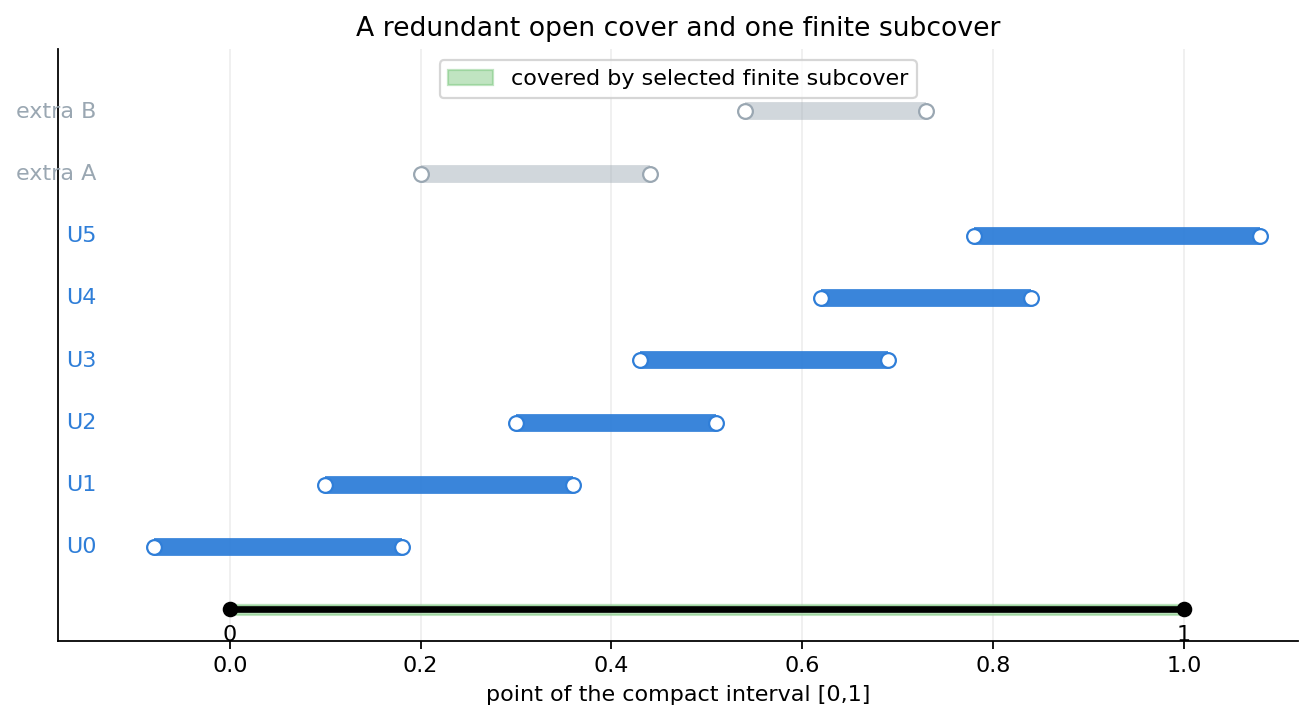

{'artifact': 'artifacts/chapter-03/figures/open-cover-finite-subcover.png',
 'cover_element_count': 8,
 'selected_subcover_names': ['U0', 'U1', 'U2', 'U3', 'U4', 'U5'],
 'selected_subcover_size': 6,
 'grid_sample_count': 2001,
 'selected_covers_grid': True,
 'uncovered_grid_points': 0,
 'grid_min_local_radius_all_cover': 0.030000000000000027}

In [3]:
cover_intervals = [
    {"name": "U0", "left": -0.08, "right": 0.18},
    {"name": "U1", "left": 0.10, "right": 0.36},
    {"name": "U2", "left": 0.30, "right": 0.51},
    {"name": "U3", "left": 0.43, "right": 0.69},
    {"name": "U4", "left": 0.62, "right": 0.84},
    {"name": "U5", "left": 0.78, "right": 1.08},
    {"name": "extra A", "left": 0.20, "right": 0.44},
    {"name": "extra B", "left": 0.54, "right": 0.73},
]


def greedy_subcover(intervals: list[dict[str, float]], start: float = 0.0, end: float = 1.0) -> list[int]:
    selected: list[int] = []
    covered_to = start
    eps = 1e-12
    while covered_to < end - eps:
        candidates = [
            (idx, item["right"])
            for idx, item in enumerate(intervals)
            if item["left"] < covered_to + eps and item["right"] > covered_to + eps
        ]
        if not candidates:
            raise ValueError(f"No interval extends coverage beyond {covered_to}")
        idx, next_right = max(candidates, key=lambda pair: pair[1])
        selected.append(idx)
        covered_to = next_right
    return selected


selected_indices = greedy_subcover(cover_intervals)
selected_names = [cover_intervals[i]["name"] for i in selected_indices]
grid = np.linspace(0.0, 1.0, 2001)
covered_by_selected = np.zeros_like(grid, dtype=bool)
for idx in selected_indices:
    item = cover_intervals[idx]
    covered_by_selected |= (item["left"] < grid) & (grid < item["right"])

local_radii = []
for x in grid:
    radii_at_x = [
        min(x - item["left"], item["right"] - x)
        for item in cover_intervals
        if item["left"] < x < item["right"]
    ]
    local_radii.append(max(radii_at_x) if radii_at_x else 0.0)
local_radii = np.array(local_radii)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot([0, 1], [0, 0], color="black", lw=3, solid_capstyle="round")
ax.scatter([0, 1], [0, 0], color="black", zorder=5)
ax.text(0, -0.25, "0", ha="center", va="top")
ax.text(1, -0.25, "1", ha="center", va="top")

for row, item in enumerate(cover_intervals):
    y = row + 1
    color = "#2f7ed8" if row in selected_indices else "#9aa7b2"
    alpha = 0.95 if row in selected_indices else 0.45
    ax.plot([item["left"], item["right"]], [y, y], color=color, lw=8, alpha=alpha, solid_capstyle="butt")
    ax.scatter([item["left"], item["right"]], [y, y], facecolors="white", edgecolors=color, s=44, zorder=4)
    ax.text(-0.14, y, item["name"], ha="right", va="center", color=color)

ax.fill_between(grid, -0.08, 0.08, where=covered_by_selected, color="#74c476", alpha=0.45, label="covered by selected finite subcover")
ax.set_xlim(-0.18, 1.12)
ax.set_ylim(-0.5, len(cover_intervals) + 1)
ax.set_yticks([])
ax.set_xlabel("point of the compact interval [0,1]")
ax.set_title("A redundant open cover and one finite subcover")
ax.legend(loc="upper center")
fig_path_open_cover = save_matplotlib(fig, UNIT, "figures", "open-cover-finite-subcover.png")
plt.close(fig)

open_cover_checks = {
    "artifact": rel(fig_path_open_cover),
    "cover_element_count": len(cover_intervals),
    "selected_subcover_names": selected_names,
    "selected_subcover_size": len(selected_indices),
    "grid_sample_count": int(grid.size),
    "selected_covers_grid": bool(covered_by_selected.all()),
    "uncovered_grid_points": int((~covered_by_selected).sum()),
    "grid_min_local_radius_all_cover": float(local_radii.min()),
}
open_cover_check_path = save_json(open_cover_checks, UNIT, "checks", "open-cover-finite-subcover.json")
assert open_cover_checks["selected_covers_grid"]
assert open_cover_checks["grid_min_local_radius_all_cover"] > 0
assert_artifact(fig_path_open_cover, min_bytes=2048)
assert_artifact(open_cover_check_path, min_bytes=256)
display_artifact(fig_path_open_cover, width=820)
open_cover_checks

## Grid Intuition For Heine-Borel

Armstrong gives two interval proofs and points out that the subdivision proof extends to a square. The model below follows the contradiction proof's geometry without copying the argument: if a cover had no finite subcover, one could keep choosing a smaller closed square still resistant to finite coverage. The nested squares have diameters tending to zero, so their intersection is forced toward one point. An open set containing that point would eventually contain the entire tiny square, contradicting the choice.

The drawing is a proof scaffold. Inspect the fixed target point, then the table of side lengths and diameters.

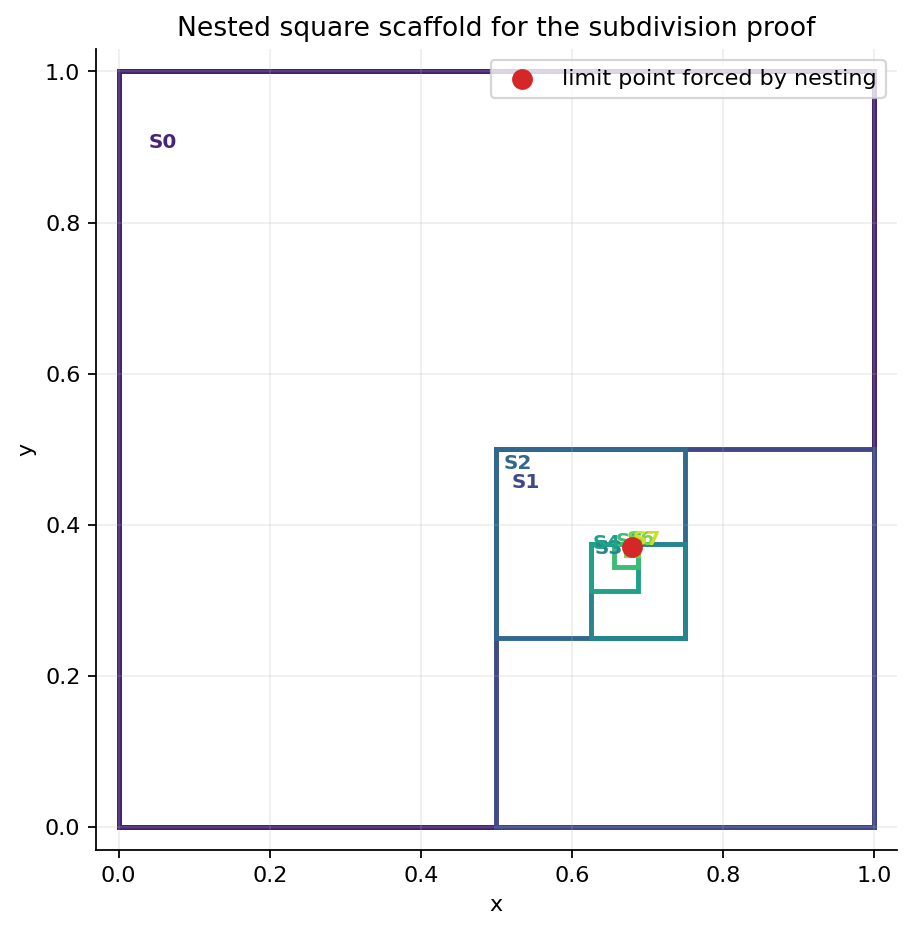

,level,x_left,y_bottom,side_length,diameter,contains_target
0,0,0.000000,0.000000,1.000000,1.414214,True
1,1,0.500000,0.000000,0.500000,0.707107,True
2,2,0.500000,0.250000,0.250000,0.353553,True
3,3,0.625000,0.250000,0.125000,0.176777,True
4,4,0.625000,0.312500,0.062500,0.088388,True
5,5,0.656250,0.343750,0.031250,0.044194,True
6,6,0.671875,0.359375,0.015625,0.022097,True
7,7,0.679688,0.367188,0.007812,0.011049,True


In [4]:
target = np.array([0.68, 0.37])
records = []
x0, y0, side = 0.0, 0.0, 1.0
for level in range(8):
    records.append({
        "level": level,
        "x_left": x0,
        "y_bottom": y0,
        "side_length": side,
        "diameter": side * math.sqrt(2),
        "contains_target": bool(x0 <= target[0] <= x0 + side and y0 <= target[1] <= y0 + side),
    })
    half = side / 2
    if target[0] >= x0 + half:
        x0 = x0 + half
    if target[1] >= y0 + half:
        y0 = y0 + half
    side = half

nested_df = pd.DataFrame(records)
nested_table_path = TABLE_DIR / "nested-square-diameters.csv"
nested_df.to_csv(nested_table_path, index=False)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.add_patch(Rectangle((0, 0), 1, 1, fill=False, edgecolor="black", lw=2.2))
colors = plt.cm.viridis(np.linspace(0.1, 0.92, len(records)))
for item, color in zip(records, colors):
    ax.add_patch(Rectangle((item["x_left"], item["y_bottom"]), item["side_length"], item["side_length"],
                           fill=False, edgecolor=color, lw=2.2))
    ax.text(item["x_left"] + item["side_length"] * 0.04,
            item["y_bottom"] + item["side_length"] * 0.90,
            f"S{item['level']}", color=color, fontsize=9, weight="bold")
ax.scatter([target[0]], [target[1]], s=70, color="#d62728", zorder=5, label="limit point forced by nesting")
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.03)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Nested square scaffold for the subdivision proof")
ax.legend(loc="upper right")
fig_path_nested = save_matplotlib(fig, UNIT, "figures", "nested-square-limit.png")
plt.close(fig)

ratios = (nested_df["diameter"].iloc[1:].to_numpy() / nested_df["diameter"].iloc[:-1].to_numpy())
nested_checks = {
    "artifact": rel(fig_path_nested),
    "table": rel(nested_table_path),
    "levels": int(len(nested_df)),
    "target": target.tolist(),
    "all_squares_contain_target": bool(nested_df["contains_target"].all()),
    "diameter_ratio_after_first": [float(v) for v in ratios],
    "final_diameter": float(nested_df["diameter"].iloc[-1]),
}
nested_check_path = save_json(nested_checks, UNIT, "checks", "nested-square-limit.json")
assert nested_checks["all_squares_contain_target"]
assert np.allclose(ratios, 0.5)
assert_artifact(fig_path_nested, min_bytes=2048)
assert_artifact(nested_table_path, min_bytes=256)
assert_artifact(nested_check_path, min_bytes=256)
display_artifact(fig_path_nested, width=620)
nested_df

## Products: Fiber Covers Become Finitely Many Strips

The product proof is a good place to slow down. A basic open set in `X x Y` is a rectangle `U x V`. For a fixed `x`, compactness of the fiber `{x} x Y` lets us choose finitely many rectangles covering that vertical fiber. Their `U`-parts have a common intersection around `x`; that intersection thickens the fiber cover into a vertical strip. Compactness of `X` then selects finitely many such strips.

The interactive HTML artifact encodes that proof with rectangles over the square. Hover over a rectangle to see which strip it belongs to. The check samples the full square and verifies that the selected rectangles cover the grid.

In [5]:
product_rectangles = [
    {"name": "R0", "strip": "Ux0", "x0": -0.05, "x1": 0.38, "y0": -0.05, "y1": 0.45},
    {"name": "R1", "strip": "Ux0", "x0": -0.05, "x1": 0.38, "y0": 0.35, "y1": 1.05},
    {"name": "R2", "strip": "Ux1", "x0": 0.30, "x1": 0.68, "y0": -0.05, "y1": 0.55},
    {"name": "R3", "strip": "Ux1", "x0": 0.30, "x1": 0.68, "y0": 0.45, "y1": 1.05},
    {"name": "R4", "strip": "Ux2", "x0": 0.60, "x1": 1.05, "y0": -0.05, "y1": 0.40},
    {"name": "R5", "strip": "Ux2", "x0": 0.60, "x1": 1.05, "y0": 0.30, "y1": 0.78},
    {"name": "R6", "strip": "Ux2", "x0": 0.60, "x1": 1.05, "y0": 0.70, "y1": 1.05},
]
strip_colors = {"Ux0": "rgba(49,130,189,0.26)", "Ux1": "rgba(49,163,84,0.26)", "Ux2": "rgba(230,85,13,0.26)"}
line_colors = {"Ux0": "#3182bd", "Ux1": "#31a354", "Ux2": "#e6550d"}

fig = go.Figure()
for rect in product_rectangles:
    fig.add_shape(
        type="rect",
        x0=rect["x0"], x1=rect["x1"], y0=rect["y0"], y1=rect["y1"],
        line={"color": line_colors[rect["strip"]], "width": 2},
        fillcolor=strip_colors[rect["strip"]],
    )
    cx = (rect["x0"] + rect["x1"]) / 2
    cy = (rect["y0"] + rect["y1"]) / 2
    fig.add_trace(go.Scatter(
        x=[cx], y=[cy], mode="markers+text", text=[rect["name"]], textposition="middle center",
        marker={"size": 1, "color": line_colors[rect["strip"]]},
        hovertemplate=(
            f"{rect['name']} in {rect['strip']}<br>"
            f"x interval=({rect['x0']:.2f}, {rect['x1']:.2f})<br>"
            f"y interval=({rect['y0']:.2f}, {rect['y1']:.2f})<extra></extra>"
        ),
        showlegend=False,
    ))

for x, label in [(0.18, "fiber over x0"), (0.50, "fiber over x1"), (0.82, "fiber over x2")]:
    fig.add_trace(go.Scatter(x=[x, x], y=[0, 1], mode="lines", line={"dash": "dot", "color": "#444"},
                             hovertemplate=label + "<extra></extra>", showlegend=False))
fig.add_shape(type="rect", x0=0, x1=1, y0=0, y1=1, line={"color": "black", "width": 3}, fillcolor="rgba(0,0,0,0)")
fig.update_layout(
    title="Product compactness as finite strip selection",
    xaxis_title="base coordinate x in X",
    yaxis_title="fiber coordinate y in Y",
    width=760,
    height=620,
    xaxis={"range": [-0.08, 1.08], "constrain": "domain"},
    yaxis={"range": [-0.08, 1.08], "scaleanchor": "x", "scaleratio": 1},
    margin={"l": 60, "r": 30, "t": 70, "b": 60},
)
product_html_path = save_plotly_html(fig, UNIT, "html", "product-strip-compactness.html", include_plotlyjs="cdn")

xx, yy = np.meshgrid(np.linspace(0, 1, 121), np.linspace(0, 1, 121))
covered_grid = np.zeros(xx.shape, dtype=bool)
for rect in product_rectangles:
    covered_grid |= (rect["x0"] < xx) & (xx < rect["x1"]) & (rect["y0"] < yy) & (yy < rect["y1"])

product_checks = {
    "artifact": rel(product_html_path),
    "rectangle_count": len(product_rectangles),
    "strip_count": len({r["strip"] for r in product_rectangles}),
    "square_grid_shape": list(covered_grid.shape),
    "selected_rectangles_cover_square_grid": bool(covered_grid.all()),
    "covered_grid_fraction": float(covered_grid.mean()),
    "fiber_x_values_shown": [0.18, 0.50, 0.82],
}
product_check_path = save_json(product_checks, UNIT, "checks", "product-strip-compactness.json")
assert product_checks["selected_rectangles_cover_square_grid"]
assert_artifact(product_html_path, min_bytes=2048)
assert_artifact(product_check_path, min_bytes=256)
display_artifact(product_html_path, width="100%", height=640)
product_checks

{'artifact': 'artifacts/chapter-03/html/product-strip-compactness.html',
 'rectangle_count': 7,
 'strip_count': 3,
 'square_grid_shape': [121, 121],
 'selected_rectangles_cover_square_grid': True,
 'covered_grid_fraction': 1.0,
 'fiber_x_values_shown': [0.18, 0.5, 0.82]}

## Continuous Images Preserve Compact And Connected Behavior

Two recurring theorems say that continuous maps cannot destroy compactness or connectedness in the image. The concrete map below is `f(t) = t(1 - t)` on `[0,1]`. The domain is compact and connected. Its image is the interval `[0,1/4]`: compact because the endpoints are included and connected because there is no gap in the image.

The symbolic check records the exact critical point and the attained bounds. This is the computational version of the theorem that a continuous real-valued function on a compact space is bounded and reaches its bounds.

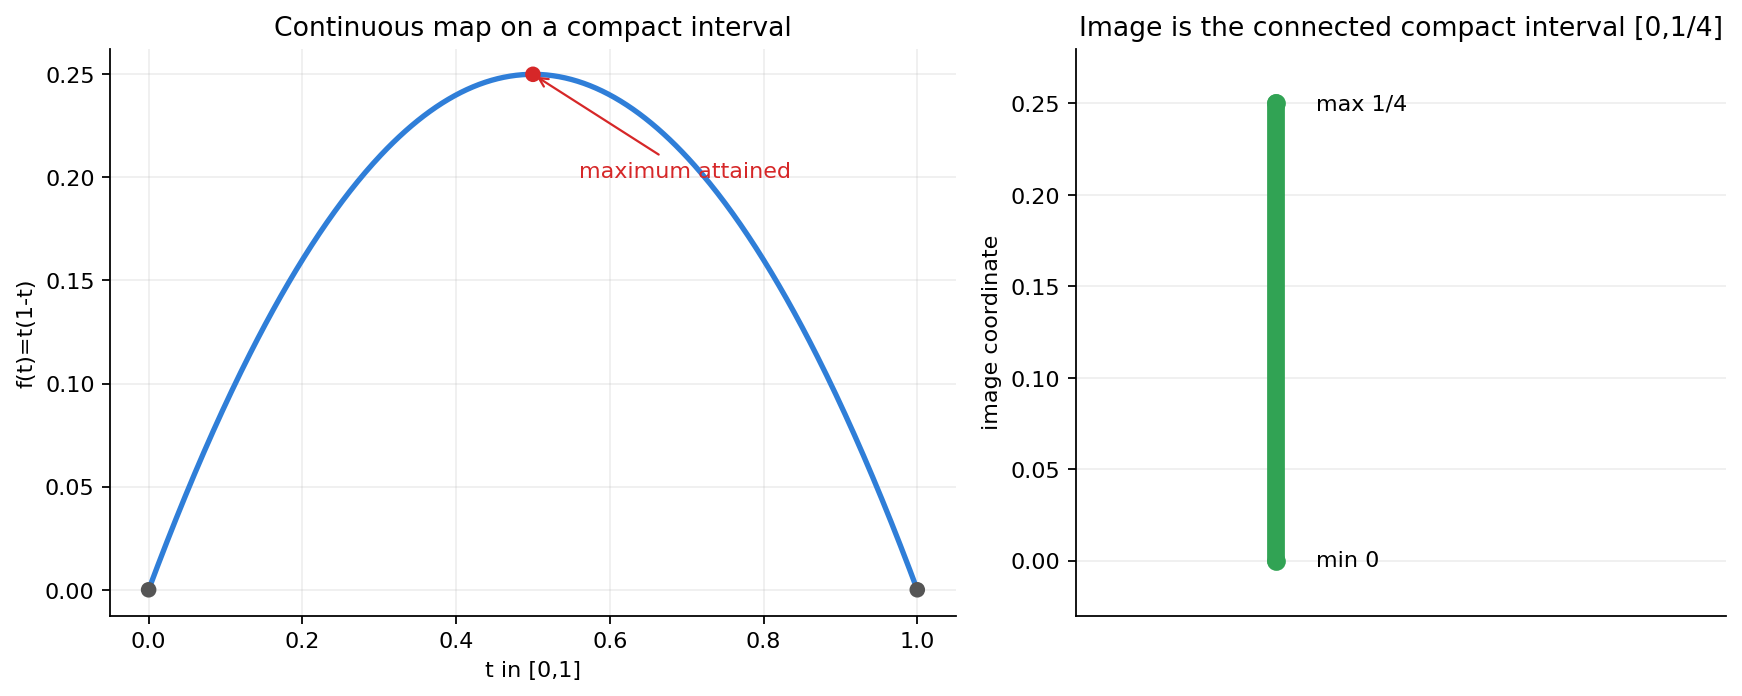

{'artifact': 'artifacts/chapter-03/figures/continuous-image-compact-connected.png',
 'map': 'f(t)=t(1-t) on [0,1]',
 'derivative': '1 - 2*t',
 'critical_points': ['1/2'],
 'critical_values': ['1/4'],
 'endpoint_values': ['0', '0'],
 'sample_min': 0.0,
 'sample_max': 0.25,
 'image_interval_connected_witness': 'sampled values fill one interval from 0 to 0.25; exact extrema are 0 and 1/4'}

In [6]:
t = sp.symbols("t", real=True)
f_expr = t * (1 - t)
derivative = sp.diff(f_expr, t)
critical_points = sp.solve(sp.Eq(derivative, 0), t)
critical_values = [sp.simplify(f_expr.subs(t, cp)) for cp in critical_points]
endpoint_values = [sp.simplify(f_expr.subs(t, 0)), sp.simplify(f_expr.subs(t, 1))]

samples = np.linspace(0, 1, 501)
values = samples * (1 - samples)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={"width_ratios": [1.3, 1]})
axes[0].plot(samples, values, color="#2f7ed8", lw=2.4)
axes[0].scatter([0, 0.5, 1], [0, 0.25, 0], color=["#555", "#d62728", "#555"], zorder=5)
axes[0].annotate("maximum attained", xy=(0.5, 0.25), xytext=(0.56, 0.20),
                 arrowprops={"arrowstyle": "->", "color": "#d62728"}, color="#d62728")
axes[0].set_title("Continuous map on a compact interval")
axes[0].set_xlabel("t in [0,1]")
axes[0].set_ylabel("f(t)=t(1-t)")

axes[1].plot([0, 0], [0, 0.25], color="#31a354", lw=8, solid_capstyle="round")
axes[1].scatter([0, 0], [0, 0.25], color="#31a354", s=55, zorder=5)
axes[1].text(0.04, 0, "min 0", va="center")
axes[1].text(0.04, 0.25, "max 1/4", va="center")
axes[1].set_xlim(-0.2, 0.45)
axes[1].set_ylim(-0.03, 0.28)
axes[1].set_xticks([])
axes[1].set_ylabel("image coordinate")
axes[1].set_title("Image is the connected compact interval [0,1/4]")
fig.tight_layout()
fig_path_continuous = save_matplotlib(fig, UNIT, "figures", "continuous-image-compact-connected.png")
plt.close(fig)

continuous_checks = {
    "artifact": rel(fig_path_continuous),
    "map": "f(t)=t(1-t) on [0,1]",
    "derivative": str(derivative),
    "critical_points": [str(cp) for cp in critical_points],
    "critical_values": [str(v) for v in critical_values],
    "endpoint_values": [str(v) for v in endpoint_values],
    "sample_min": float(values.min()),
    "sample_max": float(values.max()),
    "image_interval_connected_witness": "sampled values fill one interval from 0 to 0.25; exact extrema are 0 and 1/4",
}
continuous_check_path = save_json(continuous_checks, UNIT, "checks", "continuous-image-compact-connected.json")
assert critical_points == [sp.Rational(1, 2)]
assert critical_values == [sp.Rational(1, 4)]
assert endpoint_values == [0, 0]
assert_artifact(fig_path_continuous, min_bytes=2048)
assert_artifact(continuous_check_path, min_bytes=256)
display_artifact(fig_path_continuous, width=840)
continuous_checks

## Connectedness Versus Path Connectedness

Path connectedness implies connectedness, but not conversely. The standard plane example in this chapter is the union of the vertical segment `Y = {0} x [-1,1]` and the oscillating graph `Z = {(x, sin(1/x)) : 0 < x <= 1}`. The graph `Z` is connected because it is the continuous image of an interval. Its closure adds the vertical segment, so the whole space is connected. Yet a path starting on the vertical segment cannot escape onto the oscillating graph without violating local connected behavior near the axis.

The visual emphasizes the closure mechanism. The JSON check computes points on the graph that approach selected heights on the vertical segment, giving numerical witnesses for why the vertical segment lies in the closure.

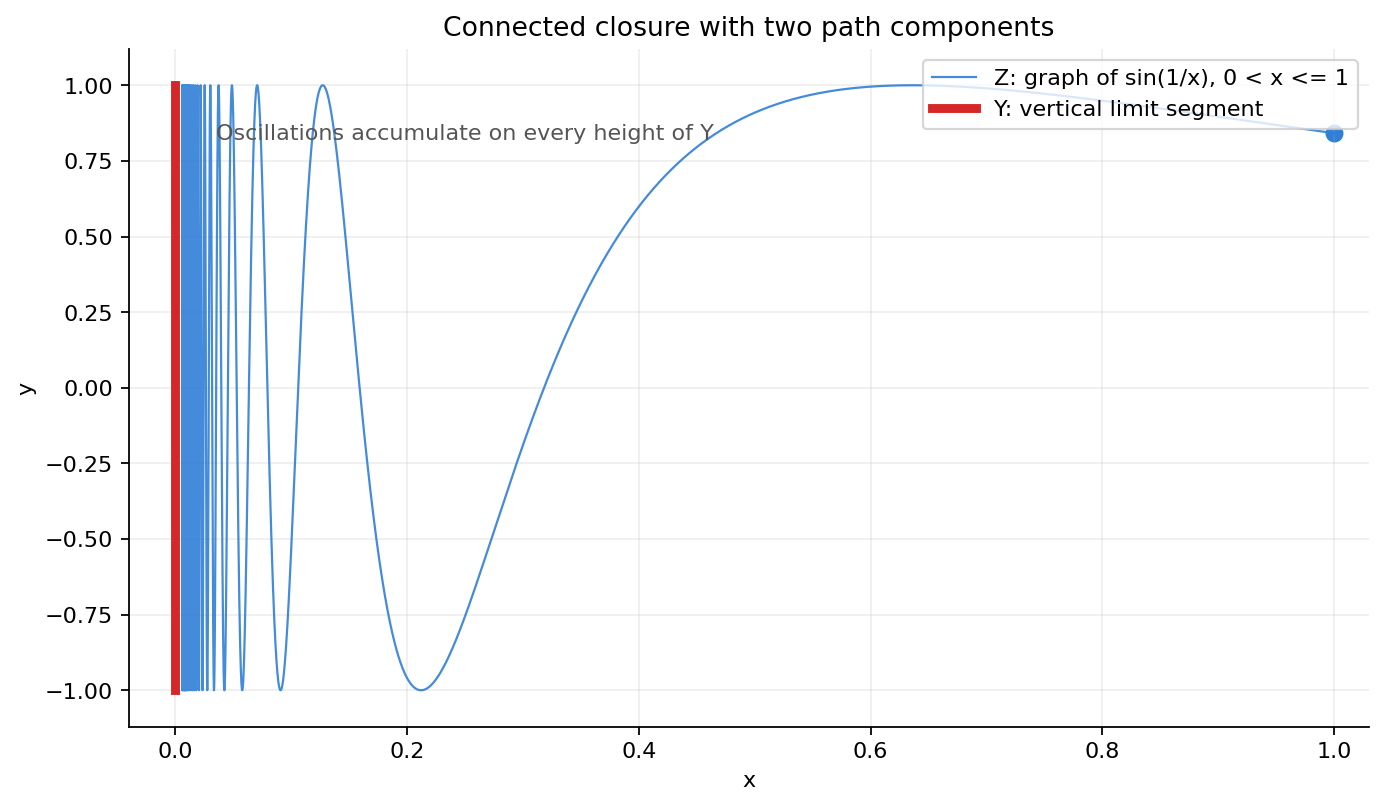

,axis_height,graph_x_near_axis,sin_1_over_x,absolute_error
0,-0.75,0.003895,-7.500000e-01,4.551914e-15
1,0.00,0.003930,2.057778e-14,2.057778e-14
2,0.75,0.003965,7.500000e-01,2.264855e-14


In [7]:
x_curve = np.geomspace(0.006, 1.0, 5500)
y_curve = np.sin(1 / x_curve)
y_axis = np.linspace(-1, 1, 400)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(x_curve, y_curve, color="#2f7ed8", lw=1.0, alpha=0.9, label="Z: graph of sin(1/x), 0 < x <= 1")
ax.plot(np.zeros_like(y_axis), y_axis, color="#d62728", lw=4, label="Y: vertical limit segment")
ax.scatter([1], [math.sin(1)], color="#2f7ed8", s=50)
ax.set_xlim(-0.04, 1.03)
ax.set_ylim(-1.12, 1.12)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Connected closure with two path components")
ax.legend(loc="upper right")
ax.text(0.035, 0.82, "Oscillations accumulate on every height of Y", color="#555")
fig_path_sine = save_matplotlib(fig, UNIT, "figures", "topologist-sine-curve.png")
plt.close(fig)

closure_witnesses = []
for level in [-0.75, 0.0, 0.75]:
    if level == 0.0:
        phase = math.pi
    else:
        phase = math.asin(level)
        if phase <= 0:
            phase += 2 * math.pi
    k = 40
    x_witness = 1 / (phase + 2 * math.pi * k)
    closure_witnesses.append({
        "axis_height": level,
        "graph_x_near_axis": x_witness,
        "sin_1_over_x": math.sin(1 / x_witness),
        "absolute_error": abs(math.sin(1 / x_witness) - level),
    })

sine_checks = {
    "artifact": rel(fig_path_sine),
    "curve_sample_count": int(x_curve.size),
    "x_min_sampled": float(x_curve.min()),
    "x_max_sampled": float(x_curve.max()),
    "vertical_segment_y_range": [float(y_axis.min()), float(y_axis.max())],
    "path_components_described": ["Y vertical segment", "Z oscillating graph"],
    "closure_witnesses": closure_witnesses,
}
sine_check_path = save_json(sine_checks, UNIT, "checks", "topologist-sine-curve.json")
assert max(item["absolute_error"] for item in closure_witnesses) < 1e-12
assert_artifact(fig_path_sine, min_bytes=2048)
assert_artifact(sine_check_path, min_bytes=256)
display_artifact(fig_path_sine, width=840)
pd.DataFrame(closure_witnesses)

## Components And Theorem Dependencies

A component is a maximal connected subset. A path component is a maximal path-connected subset. They agree in many friendly spaces, but the previous example shows that they can diverge: the whole topologist's sine curve is one connected component, while `Y` and `Z` are separate path components.

The first panel gives two component pictures. The real line with two points removed has three connected components. The sine-curve space has one connected component but two path components. The second artifact is a dependency map for this chapter's main proof moves: compactness travels through closed subsets, products, and continuous images; connectedness travels through clopen tests, products, dense closures, and paths.

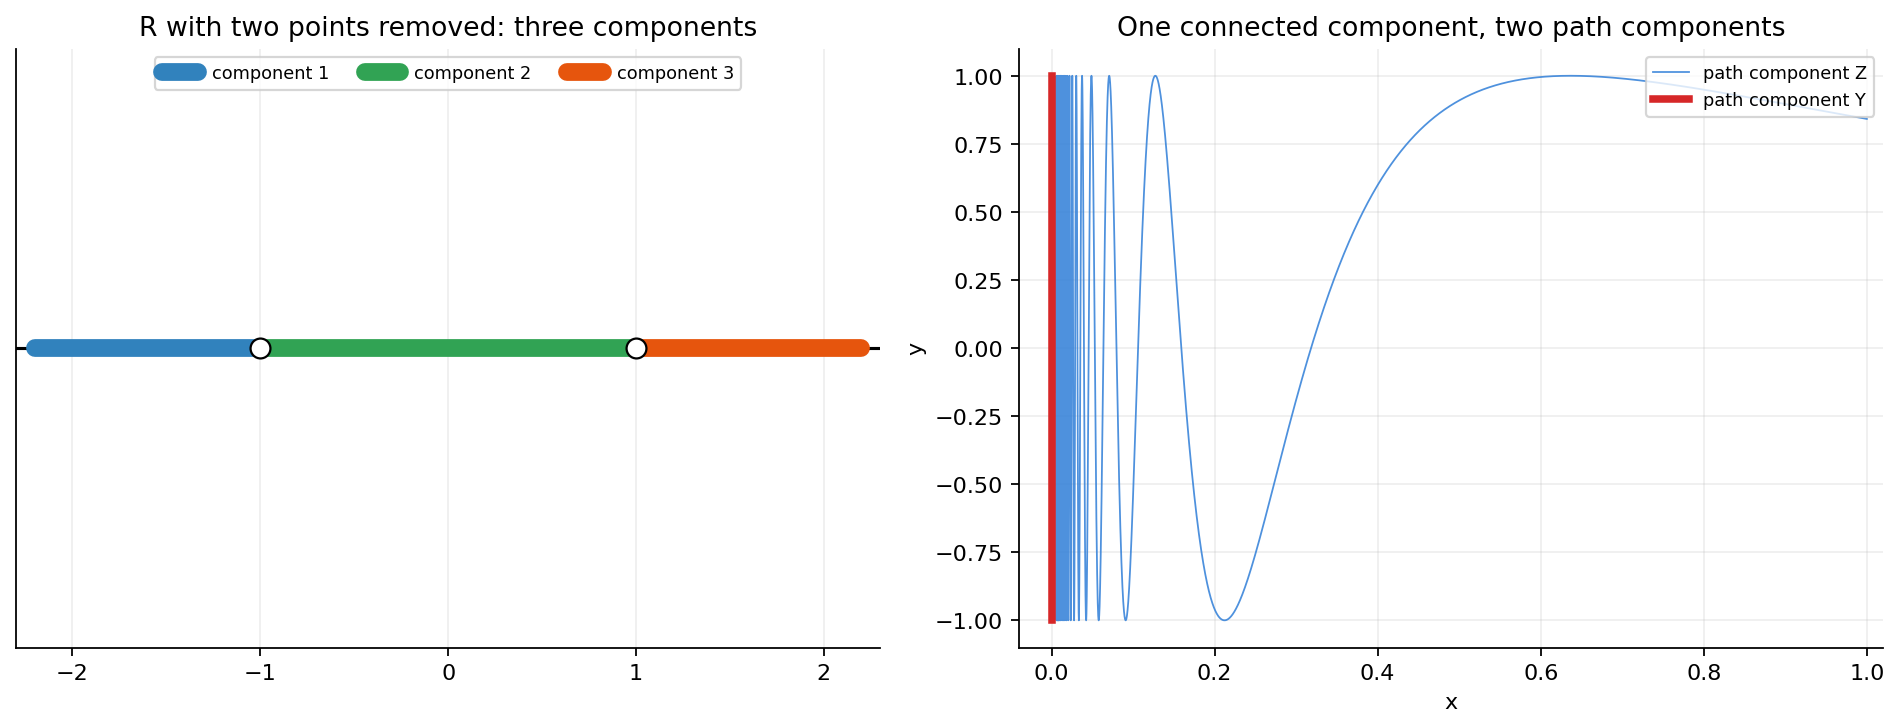

{'artifact': 'artifacts/chapter-03/figures/components-and-path-components.png',
 'finite_model': 'sampled R minus {-1,1}',
 'finite_model_component_count': 3,
 'finite_model_component_sizes': [3, 3, 5],
 'sine_curve_connected_components': 1,
 'sine_curve_path_components': 2}

In [8]:
# Finite graph witness for three components in R minus {-1, 1}.
line_points = np.array([-2.0, -1.7, -1.4, -0.7, -0.35, 0.0, 0.35, 0.7, 1.4, 1.7, 2.0])
G_line = nx.Graph()
for i, x in enumerate(line_points):
    G_line.add_node(i, x=float(x))
for i in range(len(line_points) - 1):
    a, b = line_points[i], line_points[i + 1]
    crosses_removed_point = (a < -1 < b) or (a < 1 < b)
    if not crosses_removed_point:
        G_line.add_edge(i, i + 1)
line_components = list(nx.connected_components(G_line))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
axes[0].axhline(0, color="black", lw=1.4)
interval_specs = [(-2.2, -1.03, "component 1"), (-0.97, 0.97, "component 2"), (1.03, 2.2, "component 3")]
colors = ["#3182bd", "#31a354", "#e6550d"]
for (left, right, label), color in zip(interval_specs, colors):
    axes[0].plot([left, right], [0, 0], color=color, lw=8, solid_capstyle="round", label=label)
axes[0].scatter([-1, 1], [0, 0], facecolors="white", edgecolors="black", s=80, zorder=5)
axes[0].set_xlim(-2.3, 2.3)
axes[0].set_ylim(-0.6, 0.6)
axes[0].set_yticks([])
axes[0].set_title("R with two points removed: three components")
axes[0].legend(loc="upper center", ncol=3, fontsize=8)

axes[1].plot(x_curve, y_curve, color="#2f7ed8", lw=0.8, alpha=0.85, label="path component Z")
axes[1].plot(np.zeros_like(y_axis), y_axis, color="#d62728", lw=3.4, label="path component Y")
axes[1].set_xlim(-0.04, 1.02)
axes[1].set_ylim(-1.1, 1.1)
axes[1].set_title("One connected component, two path components")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig_path_components = save_matplotlib(fig, UNIT, "figures", "components-and-path-components.png")
plt.close(fig)

component_checks = {
    "artifact": rel(fig_path_components),
    "finite_model": "sampled R minus {-1,1}",
    "finite_model_component_count": len(line_components),
    "finite_model_component_sizes": sorted([len(c) for c in line_components]),
    "sine_curve_connected_components": 1,
    "sine_curve_path_components": 2,
}
component_check_path = save_json(component_checks, UNIT, "checks", "components-and-path-components.json")
assert component_checks["finite_model_component_count"] == 3
assert component_checks["sine_curve_connected_components"] == 1
assert component_checks["sine_curve_path_components"] == 2
assert_artifact(fig_path_components, min_bytes=2048)
assert_artifact(component_check_path, min_bytes=256)
display_artifact(fig_path_components, width=900)
component_checks

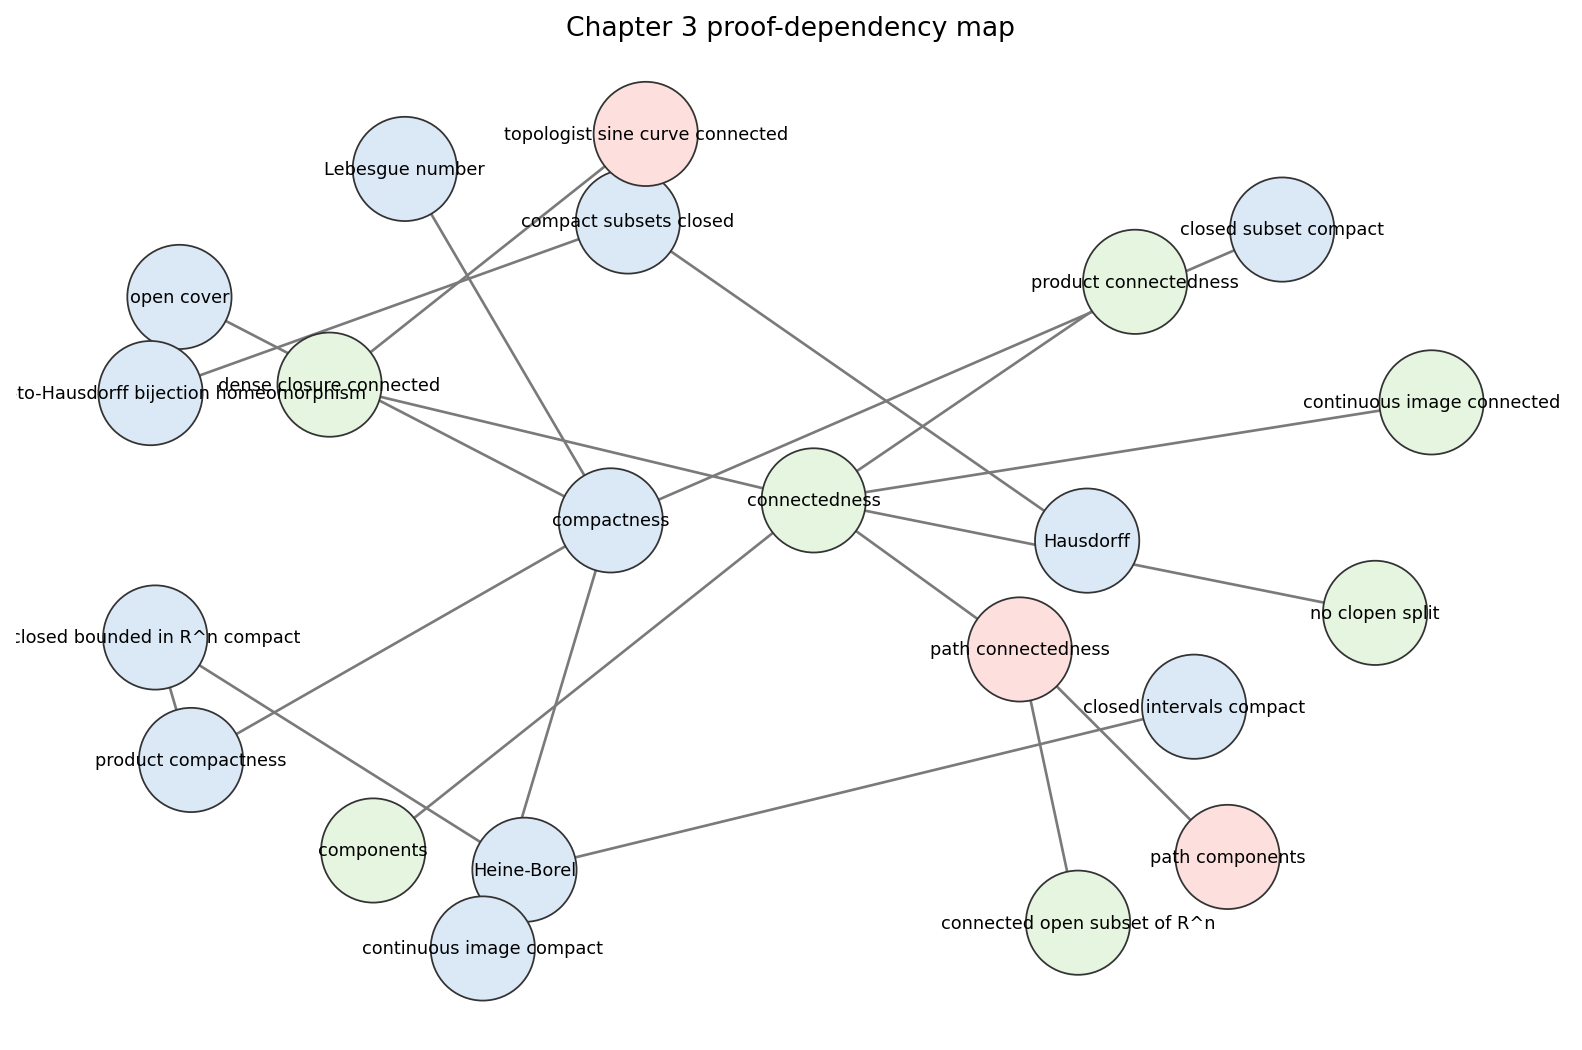

{'artifact': 'artifacts/chapter-03/figures/chapter03-proof-dependency-map.png',
 'node_count': 22,
 'edge_count': 19,
 'has_path_compactness_to_closed_bounded': True,
 'has_path_path_connected_to_connected': True,
 'has_path_dense_closure_to_sine': True}

In [9]:
dependency_edges = [
    ("open cover", "compactness"),
    ("closed intervals compact", "Heine-Borel"),
    ("Heine-Borel", "closed bounded in R^n compact"),
    ("compactness", "closed subset compact"),
    ("compactness", "continuous image compact"),
    ("compactness", "Lebesgue number"),
    ("compactness", "product compactness"),
    ("product compactness", "closed bounded in R^n compact"),
    ("Hausdorff", "compact subsets closed"),
    ("compact subsets closed", "compact-to-Hausdorff bijection homeomorphism"),
    ("no clopen split", "connectedness"),
    ("connectedness", "continuous image connected"),
    ("connectedness", "dense closure connected"),
    ("connectedness", "product connectedness"),
    ("dense closure connected", "topologist sine curve connected"),
    ("path connectedness", "connectedness"),
    ("connected open subset of R^n", "path connectedness"),
    ("connectedness", "components"),
    ("path connectedness", "path components"),
]
G = nx.DiGraph()
G.add_edges_from(dependency_edges)
pos = nx.spring_layout(G, seed=7, k=0.9)
fig, ax = plt.subplots(figsize=(12.5, 8))
node_colors = []
for node in G.nodes:
    if "compact" in node or node in {"open cover", "Heine-Borel", "closed intervals compact", "Hausdorff", "Lebesgue number"}:
        node_colors.append("#dbe9f6")
    elif "path" in node or "sine" in node:
        node_colors.append("#fde0dd")
    else:
        node_colors.append("#e5f5e0")
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=13, width=1.2, edge_color="#7a7a7a")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2200, node_color=node_colors, edgecolors="#333", linewidths=0.8)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Chapter 3 proof-dependency map")
ax.axis("off")
fig_path_dependency = save_matplotlib(fig, UNIT, "figures", "chapter03-proof-dependency-map.png")
plt.close(fig)

dependency_checks = {
    "artifact": rel(fig_path_dependency),
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "has_path_compactness_to_closed_bounded": bool(nx.has_path(G, "compactness", "closed bounded in R^n compact")),
    "has_path_path_connected_to_connected": bool(nx.has_path(G, "path connectedness", "connectedness")),
    "has_path_dense_closure_to_sine": bool(nx.has_path(G, "dense closure connected", "topologist sine curve connected")),
}
dependency_check_path = save_json(dependency_checks, UNIT, "checks", "chapter03-proof-dependency-map.json")
assert dependency_checks["has_path_compactness_to_closed_bounded"]
assert dependency_checks["has_path_path_connected_to_connected"]
assert dependency_checks["has_path_dense_closure_to_sine"]
assert_artifact(fig_path_dependency, min_bytes=2048)
assert_artifact(dependency_check_path, min_bytes=256)
display_artifact(fig_path_dependency, width=920)
dependency_checks

## Applied Lab: Cover Stress Test For Compactness

The lab compares two cover behaviors.

First, a finite sensor cover of `[0,1]` is reduced by a greedy subcover routine. This is not the general theorem; it is a practical finite-subcover calculation. Second, the family `(-0.1, 1 - 1/n)` for `n >= 2` covers `[0,1)` but every finite prefix misses a tail near `1`. That tail length is the visible obstruction to compactness for this cover.

In [10]:
sensor_centers = np.linspace(0, 1, 15)
sensor_radii = 0.095 + 0.025 * (1 + np.cos(2 * np.pi * sensor_centers)) / 2
sensor_cover = []
for idx, (center, radius) in enumerate(zip(sensor_centers, sensor_radii)):
    left = center - radius
    right = center + radius
    if idx == 0:
        left = -0.10
    if idx == len(sensor_centers) - 1:
        right = 1.10
    sensor_cover.append({"name": f"S{idx:02d}", "left": float(left), "right": float(right)})

sensor_selected_indices = greedy_subcover(sensor_cover)
sensor_grid = np.linspace(0, 1, 2001)
sensor_covered = np.zeros_like(sensor_grid, dtype=bool)
for idx in sensor_selected_indices:
    item = sensor_cover[idx]
    sensor_covered |= (item["left"] < sensor_grid) & (sensor_grid < item["right"])

prefix_ns = [2, 3, 5, 10, 25, 100]
lab_rows = []
for N in prefix_ns:
    lab_rows.append({
        "model": "[0,1) noncompact cover prefix",
        "finite_prefix_last_n": N,
        "rightmost_covered_point_below_1": 1 - 1 / N,
        "uncovered_tail_length": 1 / N,
        "covers_whole_space": False,
    })
lab_rows.append({
    "model": "[0,1] compact sensor cover",
    "finite_prefix_last_n": None,
    "rightmost_covered_point_below_1": 1.0,
    "uncovered_tail_length": 0.0,
    "covers_whole_space": bool(sensor_covered.all()),
})
lab_df = pd.DataFrame(lab_rows)
lab_table_path = TABLE_DIR / "cover-stress-test.csv"
lab_df.to_csv(lab_table_path, index=False)

lab_checks = {
    "table": rel(lab_table_path),
    "sensor_cover_size": len(sensor_cover),
    "sensor_selected_names": [sensor_cover[i]["name"] for i in sensor_selected_indices],
    "sensor_selected_size": len(sensor_selected_indices),
    "sensor_subcover_covers_grid": bool(sensor_covered.all()),
    "noncompact_cover_rule": "U_n=(-0.1, 1 - 1/n) for n>=2 covers [0,1) but no finite prefix does",
    "noncompact_prefix_tail_lengths": {str(N): 1 / N for N in prefix_ns},
}
lab_check_path = save_json(lab_checks, UNIT, "checks", "applied-lab-cover-stress.json")
assert lab_checks["sensor_subcover_covers_grid"]
assert all(length > 0 for length in lab_checks["noncompact_prefix_tail_lengths"].values())
assert_artifact(lab_table_path, min_bytes=256)
assert_artifact(lab_check_path, min_bytes=256)
display(lab_df)
lab_checks

,model,finite_prefix_last_n,rightmost_covered_point_below_1,uncovered_tail_length,covers_whole_space
0,"[0,1) noncompact cover prefix",2.0,0.500000,0.500000,False
1,"[0,1) noncompact cover prefix",3.0,0.666667,0.333333,False
2,"[0,1) noncompact cover prefix",5.0,0.800000,0.200000,False
3,"[0,1) noncompact cover prefix",10.0,0.900000,0.100000,False
4,"[0,1) noncompact cover prefix",25.0,0.960000,0.040000,False
5,"[0,1) noncompact cover prefix",100.0,0.990000,0.010000,False
6,"[0,1] compact sensor cover",NaN,1.000000,0.000000,True


{'table': 'artifacts/chapter-03/tables/cover-stress-test.csv',
 'sensor_cover_size': 15,
 'sensor_selected_names': ['S01', 'S04', 'S06', 'S08', 'S10', 'S13'],
 'sensor_selected_size': 6,
 'sensor_subcover_covers_grid': True,
 'noncompact_cover_rule': 'U_n=(-0.1, 1 - 1/n) for n>=2 covers [0,1) but no finite prefix does',
 'noncompact_prefix_tail_lengths': {'2': 0.5,
  '3': 0.3333333333333333,
  '5': 0.2,
  '10': 0.1,
  '25': 0.04,
  '100': 0.01}}

## Final Sanity Checks

The final cell treats the generated artifacts as part of the lesson. It checks that the notebook has no calls to the generic course visual shell, that each artifact exists and is nonempty, and that the core invariants asserted in the prose are present in the JSON outputs.

In [11]:
expected_artifacts = [
    storyboard_path,
    fig_path_open_cover,
    open_cover_check_path,
    fig_path_nested,
    nested_table_path,
    nested_check_path,
    product_html_path,
    product_check_path,
    fig_path_continuous,
    continuous_check_path,
    fig_path_sine,
    sine_check_path,
    fig_path_components,
    component_check_path,
    fig_path_dependency,
    dependency_check_path,
    lab_table_path,
    lab_check_path,
]

for path in expected_artifacts:
    min_size = 2048 if path.suffix.lower() in {".png", ".html"} else 128
    assert_artifact(path, min_bytes=min_size)

notebook_path = BOOK_ROOT / "chapter-03-compactness-and-connectedness" / "03-compactness-and-connectedness.ipynb"
notebook_text = notebook_path.read_text(encoding="utf-8")
for forbidden in ["build_" + "unit_visuals", "run_" + "unit_lab"]:
    assert forbidden not in notebook_text

loaded_checks = {
    "open_cover": json.loads(open_cover_check_path.read_text(encoding="utf-8")),
    "nested": json.loads(nested_check_path.read_text(encoding="utf-8")),
    "product": json.loads(product_check_path.read_text(encoding="utf-8")),
    "continuous": json.loads(continuous_check_path.read_text(encoding="utf-8")),
    "sine": json.loads(sine_check_path.read_text(encoding="utf-8")),
    "components": json.loads(component_check_path.read_text(encoding="utf-8")),
    "dependency": json.loads(dependency_check_path.read_text(encoding="utf-8")),
    "lab": json.loads(lab_check_path.read_text(encoding="utf-8")),
}
assert loaded_checks["open_cover"]["selected_covers_grid"]
assert loaded_checks["nested"]["all_squares_contain_target"]
assert loaded_checks["product"]["selected_rectangles_cover_square_grid"]
assert loaded_checks["continuous"]["critical_values"] == ["1/4"]
assert max(item["absolute_error"] for item in loaded_checks["sine"]["closure_witnesses"]) < 1e-12
assert loaded_checks["components"]["finite_model_component_count"] == 3
assert loaded_checks["dependency"]["has_path_path_connected_to_connected"]
assert loaded_checks["lab"]["sensor_subcover_covers_grid"]

check_summary = pd.DataFrame([
    {"check_group": name, "status": "passed", "artifact_or_claim": value.get("artifact", value.get("table", "json invariant"))}
    for name, value in loaded_checks.items()
])
check_summary

,check_group,status,artifact_or_claim
0,open_cover,passed,artifacts/chapter-03/figures/open-cover-finite...
1,nested,passed,artifacts/chapter-03/figures/nested-square-lim...
2,product,passed,artifacts/chapter-03/html/product-strip-compac...
3,continuous,passed,artifacts/chapter-03/figures/continuous-image-...
4,sine,passed,artifacts/chapter-03/figures/topologist-sine-c...
5,components,passed,artifacts/chapter-03/figures/components-and-pa...
6,dependency,passed,artifacts/chapter-03/figures/chapter03-proof-d...
7,lab,passed,artifacts/chapter-03/tables/cover-stress-test.csv


## Takeaways

- Compactness turns arbitrary open-cover data into finite evidence. On closed bounded Euclidean sets this matches the Heine-Borel picture.
- The subdivision proof is a limiting argument: nested closed sets with shrinking diameters force attention onto one point.
- Product compactness is not just "compact times compact." The proof chooses finite fiber covers, thickens them to strips, then selects finitely many strips over the base.
- Connectedness forbids a clopen split; path connectedness asks for continuous routes. The topologist's sine curve separates those ideas cleanly.
- Components are maximal connected pieces, while path components are maximal route-connected pieces. They need not agree.
- Continuous images preserve compactness and connectedness, so extrema and interval images are not accidental features of the examples.